In [1]:
from gammapy.data import DataStore
from gammapy.irf import Background3D

from scipy.interpolate import interp1d
import numpy as np

import math
import astropy
import os
import pandas as pd
import astropy.units as u
from astropy.units import Quantity
import astropy.constants as cst

import matplotlib.pyplot as plt
import pylab
from operator import truediv

from scipy.optimize import fsolve
from scipy import signal
from scipy.integrate import quad, nquad, dblquad

from gammapy.stats import WStatCountsStatistic

from gammapy.irf import EffectiveAreaTable2D, load_cta_irfs

In [2]:
def masses_list(filename_masses): # final version
    #print('mass:', mass)# in GeV
    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
        # ~ print(data.dtype.names)

    masses_list = np.array(sorted(set(data['MDM'])))

    return masses_list# GeV


In [3]:
def ID_limits(filename): # final version
    #print('mass:', mass)# in GeV
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
        # ~ print(data.dtype.names)

    sigma = np.array(data['SigmaV'])
    masses = np.array(data['mDM'])
    
    return masses, sigma


In [4]:
def Sigma_CA(filename_masses):

    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
    masses_list = np.array(sorted(set(data['MDM'])))
    sigma_CA = []
    for mass in masses_list:
        sigma = np.mean(np.array(data['SigmaV'][(data['MDM'] == mass)]))
        sigma_CA.append(sigma)
    #sigma_list = np.array(sorted(set(data['SigmaV'])))
    
    return np.array(sigma_CA)



In [14]:
filenames_CA = [
    'CA_sig_11all','CA_sig_12all','CA_sig_13all','CA_sig_14all',
    'CA_sig_21all','CA_sig_22all','CA_sig_23all','CA_sig_24all',
    'CA_sig_31all','CA_sig_32all','CA_sig_33all','CA_sig_34all',
    'CA_sig_41all','CA_sig_42all','CA_sig_43all','CA_sig_44all'  
            ] # gamma spectrum filenames

benchmark = [
    '11','12','13','14',
    '21','22','23','24',
    '31','32','33','34',
    '41','42','43','44'
        ]


#table_ID = open('ID11.dat','r')
#table_ID.readline()
#table_ID.readline()
#table_ID.readline()
#Columns_ID = table_ID.readline().split()

#data_ID = np.genfromtxt('ID11.dat',dtype=float, comments='#')[1:,:]
#table_ID.close()

#values_ID = pd.DataFrame(data_ID,columns=Columns_ID)
#values_ID


#values_ID = []
sigmav_CA = []
sigmav_ID = []
sigmav_IDv2 = []
sigmav_HESS = []
sigmav_HESS546 = []
sigmav_HESS546v2 = []
sigmav_CD = []
mass_range = []
mass_rangeHESS = []
mass_range_DD = []

for b in benchmark:
    #table_ID = open('ID'+b+'.dat','r')
    #table_ID.readline()
    #table_ID.readline()
    #table_ID.readline()
    #Columns_ID = table_ID.readline().split()

    #data_ID = np.genfromtxt('ID'+b+'.dat',dtype=float, comments='#')[1:,:]
    #table_ID.close()

    #values_ID.append(pd.DataFrame(data_ID,columns=Columns_ID)
    if ((b != '44') and (b != '14')):
        sigmav_CA.append(Sigma_CA('CA_sig_'+b+'all'))
        sigmav_ID.append(ID_limits('ID'+b+'.dat')[1])
        sigmav_IDv2.append(ID_limits('ID'+b+'_v2.dat')[1])
        sigmav_HESS.append(ID_limits('ID_HESS'+b+'.dat')[1])
        sigmav_HESS546.append(ID_limits('ID_HESS'+b+'_546h.dat')[1])
        sigmav_HESS546v2.append(ID_limits('ID_HESS'+b+'_546h_v2.dat')[1])
        mass_range.append(masses_list('CA_sig_'+b+'all'))
        mass_rangeHESS.append(ID_limits('ID_HESS'+b+'_546h_v2.dat')[0])
        
    else:
        sigmav_CA.append([])
        sigmav_ID.append([])
        sigmav_IDv2.append([])
        sigmav_HESS.append([])
        sigmav_HESS546.append([])
        sigmav_HESS546v2.append([])
        mass_range.append([])
        mass_rangeHESS.append([])

    #print(b)    
    #sigmav_CD.append(Sigma_CA('CD_sig_'+b+'all_XENONnT'))
    sigmav_CD.append(Sigma_CA('CD_sig_'+b+'all_LZ'))
    #mass_range_DD.append(masses_list('CD_sig_'+b+'all'))
    #mass_range_DD.append(masses_list('CD_sig_'+b+'all_XENONnT'))
    mass_range_DD.append(masses_list('CD_sig_'+b+'all_LZ'))
    #values_ID
    #print(Sigma_CA('CA_sig_'+b+'all'))


In [23]:
# Unitarity limit
#uni = open('Unitarity.dat','r')
filename_uni = 'Unitarity3.dat'
lines = []
with open(filename_uni) as f:
    for line in f:
        if not line.startswith('#'):
            lines.append(line)
    data_uni = np.genfromtxt (lines, names = True ,dtype = None)
    # ~ print(data.dtype.names)





#uni.close()

In [24]:
data_uni

array([(4.34393761, 21222.62267239,  0.5,  5. ),
       (4.2652921 , 20945.36458305,  1. ,  5. ),
       (4.8524429 , 19360.48989122,  5. ,  0.5),
       (4.91657795, 20122.83348782,  5. ,  1. ),
       (3.58791137, 20787.12342436,  5. ,  5. ),
       (0.23489775, 21293.66484178,  5. , 10. ),
       (1.6319362 , 13467.38344407, 10. ,  0.5),
       (1.65825222, 13699.84144156, 10. ,  1. ),
       (1.39541759, 16836.71230124, 10. ,  5. )],
      dtype=[('Lambda345', '<f8'), ('MDM', '<f8'), ('d0', '<f8'), ('dplus', '<f8')])

In [25]:
mass_uni = data_uni['MDM']*0.9

In [26]:
len(Sigma_CA('CA_sig_11all'))

29

In [27]:
len(masses_list('CA_sig_11all'))

29

<Figure size 640x480 with 0 Axes>

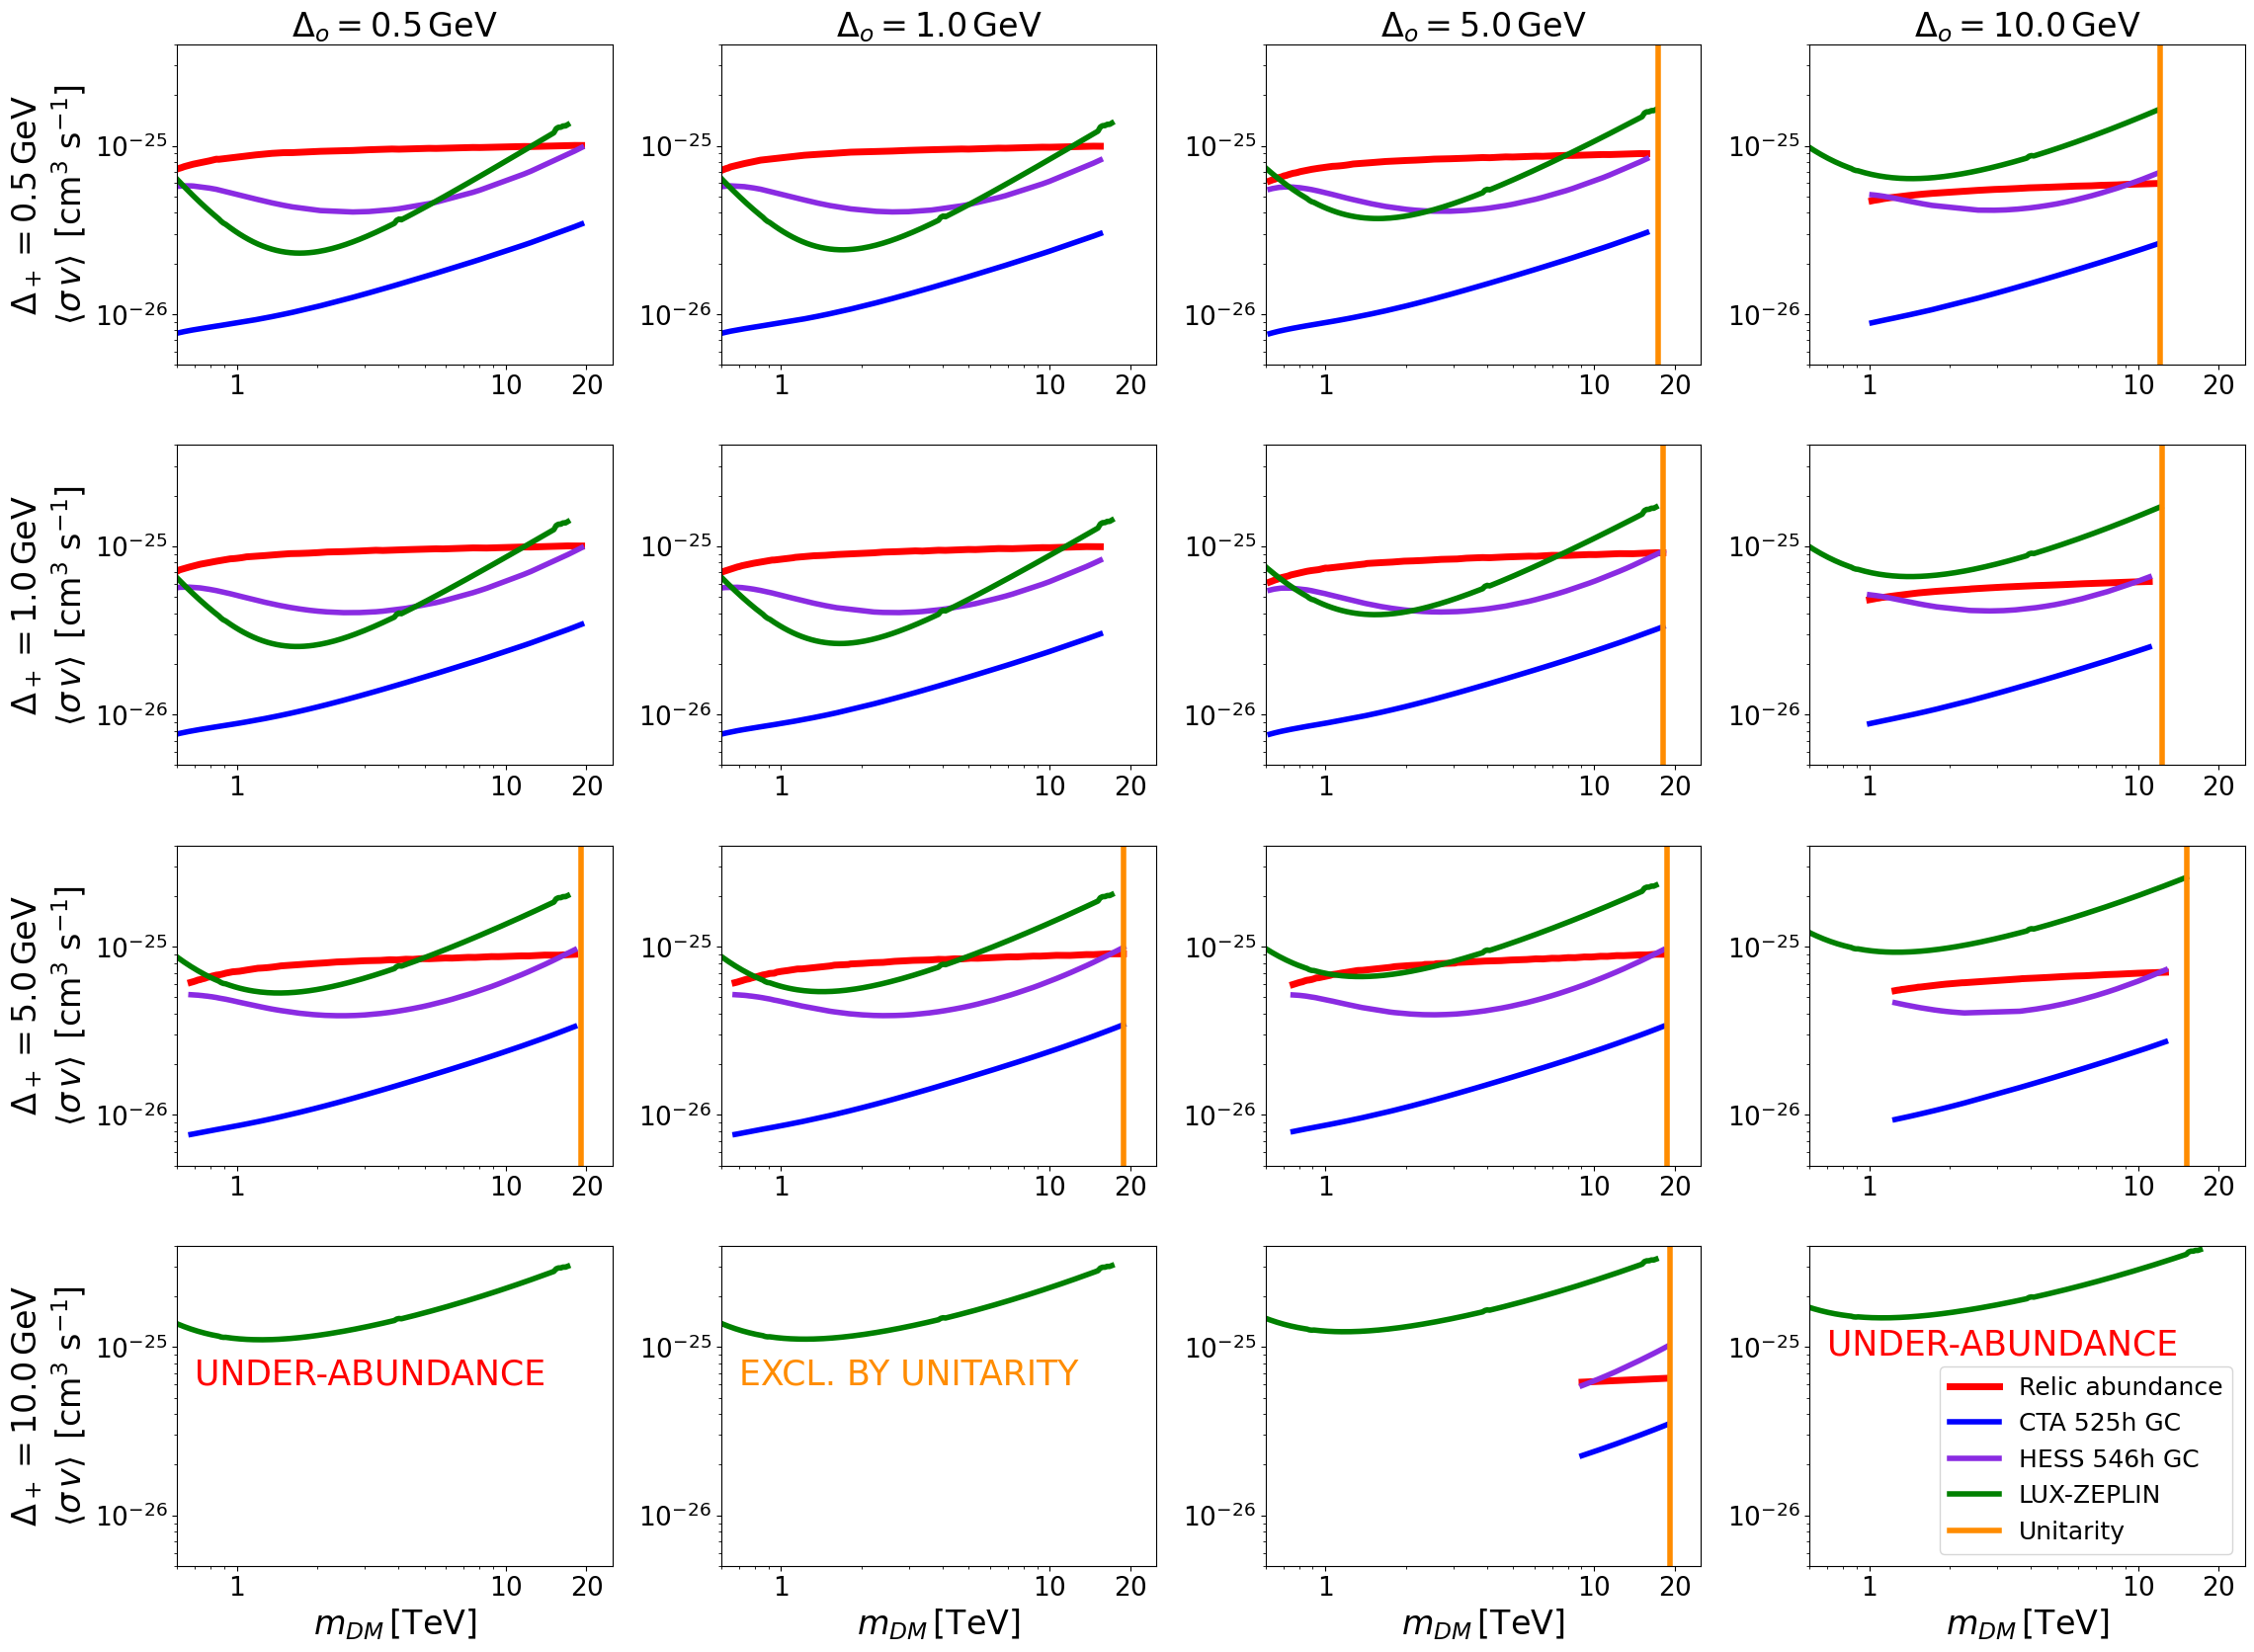

In [22]:
plt.figure(5)
fig, axs = plt.subplots(4, 4,figsize=(27,20), sharey=False)
fig.subplots_adjust(hspace=0.25,wspace=0.25)# 0.023 0.05

M_b = np.geomspace(500,30000,100)


axs[0,0].plot(mass_range[0],sigmav_CA[0],label='Relic abundance for IDM',color='red',linewidth=5)
axs[0,0].plot(mass_range[0],sigmav_ID[0],label='CTA 500 h GC',color='blue',linestyle='solid',linewidth=4)
#axs[0,0].plot(mass_range[0],sigmav_HESS[0],label='HESS 254 h GC',color='blue',linestyle='solid',linewidth=4)
axs[0,0].plot(mass_range[0],sigmav_HESS546[0],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[0,0].plot(mass_range_DD[0],sigmav_CD[0],label='LZ',color='green',linewidth=4)
#axs[0,0].plot(mass_range[0],values_ID[0]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,0].axhline(y=3e-26,color='red')
#axs[0,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[0,1].plot(mass_range[4],sigmav_CA[4],label='Relic abundance for IDM',color='red',linewidth=5)
axs[0,1].plot(mass_range[4],sigmav_ID[4],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[0,1].plot(mass_range[4],sigmav_HESS[4],label='HESS',color='blue',linestyle='solid',linewidth=4)
axs[0,1].plot(mass_range[4],sigmav_HESS546[4],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[0,1].plot(mass_range_DD[4],sigmav_CD[4],label='DD exclusion',color='green',linewidth=4)
#axs[0,1].plot(mass_range[3],values_ID[3]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,1].axhline(y=3e-26,color='red')
#axs[0,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[0,2].plot(mass_range[8][(mass_range[8] < mass_uni[2])],sigmav_CA[8][(mass_range[8] < mass_uni[2])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[0,2].plot(mass_range[8][(mass_range[8] < mass_uni[2])],sigmav_ID[8][(mass_range[8] < mass_uni[2])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[0,2].plot(mass_range[8],sigmav_HESS[8],label='HESS',color='blue',linestyle='solid',linewidth=4)
axs[0,2].plot(mass_range[8][(mass_range[8] < mass_uni[2])],sigmav_HESS546[8][(mass_range[8] < mass_uni[2])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[0,2].plot(mass_range_DD[8][(mass_range_DD[8] < mass_uni[2])],sigmav_CD[8][(mass_range_DD[8] < mass_uni[2])],label='DD exclusion',color='green',linewidth=4)
#axs[0,2].plot(mass_range[6],values_ID[6]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,2].axhline(y=3e-26,color='red')
#axs[0,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[0,3].plot(mass_range[12][(mass_range[12] < mass_uni[6])],sigmav_CA[12][(mass_range[12] < mass_uni[6])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[0,3].plot(mass_range[12][(mass_range[12] < mass_uni[6])],sigmav_ID[12][(mass_range[12] < mass_uni[6])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[0,3].plot(mass_range[12],sigmav_HESS[12],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[0,3].plot(mass_range[12][(mass_range[12] < mass_uni[6])],sigmav_HESS546[12][(mass_range[12] < mass_uni[6])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[0,3].plot(mass_range_DD[12][(mass_range_DD[12] < mass_uni[6])],sigmav_CD[12][(mass_range_DD[12] < mass_uni[6])],label='DD exclusion',color='green',linewidth=4)
#axs[0,3].plot(mass_range[9],values_ID[9]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,3].axhline(y=3e-26,color='red')
#axs[0,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[1,0].plot(mass_range[1],sigmav_CA[1],label='Relic abundance for IDM',color='red',linewidth=5)
axs[1,0].plot(mass_range[1],sigmav_ID[1],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[1,0].plot(mass_range[1],sigmav_HESS[1],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[1,0].plot(mass_range[1],sigmav_HESS546[1],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[1,0].plot(mass_range_DD[1],sigmav_CD[1],label='DD exclusion',color='green',linewidth=4)
#axs[1,0].plot(mass_range[1],values_ID[1]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,0].axhline(y=3e-26,color='red')
#axs[1,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[1,1].plot(mass_range[5],sigmav_CA[5],label='Relic abundance for IDM',color='red',linewidth=5)
axs[1,1].plot(mass_range[5],sigmav_ID[5],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[1,1].plot(mass_range[5],sigmav_HESS[5],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[1,1].plot(mass_range[5],sigmav_HESS546[5],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[1,1].plot(mass_range_DD[5],sigmav_CD[5],label='DD exclusion',color='green',linewidth=4)
#axs[1,1].plot(mass_range[4],values_ID[4]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,1].axhline(y=3e-26,color='red')
#axs[1,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[1,2].plot(mass_range[9][(mass_range[9] < mass_uni[3])],sigmav_CA[9][(mass_range[9] < mass_uni[3])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[1,2].plot(mass_range[9][(mass_range[9] < mass_uni[3])],sigmav_ID[9][(mass_range[9] < mass_uni[3])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[1,2].plot(mass_range[9],sigmav_HESS[9],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[1,2].plot(mass_range[9][(mass_range[9] < mass_uni[3])],sigmav_HESS546[9][(mass_range[9] < mass_uni[3])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[1,2].plot(mass_range_DD[9][(mass_range_DD[9] < mass_uni[3])],sigmav_CD[9][(mass_range_DD[9] < mass_uni[3])],label='DD exclusion',color='green',linewidth=4)
#axs[1,2].plot(mass_range[7],values_ID[7]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,2].axhline(y=3e-26,color='red')
#axs[1,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[1,3].plot(mass_range[13][(mass_range[13] < mass_uni[7])],sigmav_CA[13][(mass_range[13] < mass_uni[7])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[1,3].plot(mass_range[13][(mass_range[13] < mass_uni[7])],sigmav_ID[13][(mass_range[13] < mass_uni[7])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[1,3].plot(mass_range[13],sigmav_HESS[13],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[1,3].plot(mass_range[13][(mass_range[13] < mass_uni[7])],sigmav_HESS546[13][(mass_range[13] < mass_uni[7])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[1,3].plot(mass_range_DD[13][(mass_range_DD[13] < mass_uni[7])],sigmav_CD[13][(mass_range_DD[13] < mass_uni[7])],label='DD exclusion',color='green',linewidth=4)
#axs[1,3].plot(mass_range[10],values_ID[10]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,3].axhline(y=3e-26,color='red')
#axs[1,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[2,0].plot(mass_range[2][(mass_range[2] < mass_uni[0])],sigmav_CA[2][(mass_range[2] < mass_uni[0])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[2,0].plot(mass_range[2][(mass_range[2] < mass_uni[0])],sigmav_ID[2][(mass_range[2] < mass_uni[0])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[2,0].plot(mass_range[2],sigmav_HESS[2],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[2,0].plot(mass_range[2][(mass_range[2] < mass_uni[0])],sigmav_HESS546[2][(mass_range[2] < mass_uni[0])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[2,0].plot(mass_range_DD[2][(mass_range_DD[2] < mass_uni[0])],sigmav_CD[2][(mass_range_DD[2] < mass_uni[0])],label='DD exclusion',color='green',linewidth=4)
#axs[2,0].plot(mass_range[2],values_ID[2]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,0].axhline(y=3e-26,color='red')
#axs[2,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[2,1].plot(mass_range[6][(mass_range[6] < mass_uni[1])],sigmav_CA[6][(mass_range[6] < mass_uni[1])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[2,1].plot(mass_range[6][(mass_range[6] < mass_uni[1])],sigmav_ID[6][(mass_range[6] < mass_uni[1])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[2,1].plot(mass_range[6],sigmav_HESS[6],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[2,1].plot(mass_range[6][(mass_range[6] < mass_uni[1])],sigmav_HESS546[6][(mass_range[6] < mass_uni[1])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[2,1].plot(mass_range_DD[6][(mass_range_DD[6] < mass_uni[1])],sigmav_CD[6][(mass_range_DD[6] < mass_uni[1])],label='DD exclusion',color='green',linewidth=4)
#axs[2,1].plot(mass_range[5],values_ID[5]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,1].axhline(y=3e-26,color='red')
#axs[2,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[2,2].plot(mass_range[10][(mass_range[10] < mass_uni[4])],sigmav_CA[10][(mass_range[10] < mass_uni[4])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[2,2].plot(mass_range[10][(mass_range[10] < mass_uni[4])],sigmav_ID[10][(mass_range[10] < mass_uni[4])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[2,2].plot(mass_range[10],sigmav_HESS[10],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[2,2].plot(mass_range[10][(mass_range[10] < mass_uni[4])],sigmav_HESS546[10][(mass_range[10] < mass_uni[4])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[2,2].plot(mass_range_DD[10][(mass_range_DD[10] < mass_uni[4])],sigmav_CD[10][(mass_range_DD[10] < mass_uni[4])],label='DD exclusion',color='green',linewidth=4)
#axs[2,2].plot(mass_range[8],values_ID[8]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,2].axhline(y=3e-26,color='red')
#axs[2,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[2,3].plot(mass_range[14][(mass_range[14] < mass_uni[8])],sigmav_CA[14][(mass_range[14] < mass_uni[8])],label='Relic abundance constraint',color='red',linewidth=5)
axs[2,3].plot(mass_range[14][(mass_range[14] < mass_uni[8])],sigmav_ID[14][(mass_range[14] < mass_uni[8])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[2,3].plot(mass_range[14],sigmav_HESS[14],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[2,3].plot(mass_range[14][(mass_range[14] < mass_uni[8])],sigmav_HESS546[14][(mass_range[14] < mass_uni[8])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[2,3].plot(mass_range_DD[14][(mass_range_DD[14] < mass_uni[8])],sigmav_CD[14][(mass_range_DD[14] < mass_uni[8])],label='DD exclusion',color='green',linewidth=4)
#axs[2,3].plot(mass_range[11],values_ID[11]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,3].axhline(y=3e-26,color='red')
#axs[2,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[3,0].plot(mass_range[3],sigmav_CA[3],label='IDM relic abundance',color='red',linewidth=5)
axs[3,0].plot(mass_range[3],sigmav_ID[3],label='CTA 525h GC',color='blue',linestyle='solid',linewidth=4)
#axs[3,0].plot(mass_range[3],sigmav_HESS[3],label='HESS 254h GC',color='blue',linestyle='solid',linewidth=4)
axs[3,0].plot(mass_range[3],sigmav_HESS546[3],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[3,0].plot(mass_range_DD[3],sigmav_CD[3],label='XENONnT',color='green',linewidth=4)
#axs[2,0].plot(mass_range[2],values_ID[2]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,0].axhline(y=3e-26,color='red')
#axs[2,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

#axs[3,1].plot(mass_range[7],sigmav_CA[7],label='Relic abundance for IDM',color='red',linewidth=5)
#axs[3,1].plot(mass_range[7],sigmav_ID[7],label='CTA',color='blue',linestyle='dotted',linewidth=4)
#axs[3,1].plot(mass_range[7],sigmav_HESS[7],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[3,1].plot(mass_range[7],sigmav_HESS546[7],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=4)
axs[3,1].plot(mass_range_DD[7],sigmav_CD[7],label='DD exclusion',color='green',linewidth=4)
#axs[2,1].plot(mass_range[5],values_ID[5]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,1].axhline(y=3e-26,color='red')
#axs[2,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[3,2].plot(mass_range[11][(mass_range[11] < mass_uni[5])],sigmav_CA[11][(mass_range[11] < mass_uni[5])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[3,2].plot(mass_range[11][(mass_range[11] < mass_uni[5])],sigmav_ID[11][(mass_range[11] < mass_uni[5])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[3,2].plot(mass_range[11],sigmav_HESS[11],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[3,2].plot(mass_range[11][(mass_range[11] < mass_uni[5])],sigmav_HESS546[11][(mass_range[11] < mass_uni[5])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[3,2].plot(mass_range_DD[11][(mass_range_DD[11] < mass_uni[5])],sigmav_CD[11][(mass_range_DD[11] < mass_uni[5])],label='DD exclusion',color='green',linewidth=4)
#axs[2,2].plot(mass_range[8],values_ID[8]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,2].axhline(y=3e-26,color='red')
#axs[2,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[3,3].plot(mass_range[15],sigmav_CA[15],label='Relic abundance',color='red',linewidth=5)
axs[3,3].plot(mass_range[15],sigmav_ID[15],label='CTA 525h GC',color='blue',linestyle='solid',linewidth=4)
#axs[3,3].plot(mass_range[15],sigmav_HESS[15],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[3,3].plot(mass_range[15],sigmav_HESS546[15],label='HESS 546h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[3,3].plot(mass_range_DD[15],sigmav_CD[15],label='LUX-ZEPLIN',color='green',linewidth=4)
axs[3,3].plot([],[],label='Unitarity',color='darkorange',linewidth=4)
#axs[2,3].plot(mass_range[11],values_ID[11]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,3].axhline(y=3e-26,color='red')
#axs[2,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

#axs[0,0].vlines(mass_uni[0],1e-27,1e-24,color='darkorange',linewidth=5)
#axs[1,0].vlines(mass_uni[1],1e-27,1e-24,color='darkorange',linewidth=5)
axs[2,0].vlines(mass_uni[0],1e-27,1e-24,color='darkorange',linewidth=4)

axs[2,1].vlines(mass_uni[1],1e-27,1e-24,color='darkorange',linewidth=4)
#axs[1,1].vlines(mass_uni[4],1e-27,1e-24,color='darkorange',linewidth=5)
#axs[2,1].vlines(mass_uni[5],1e-27,1e-24,color='darkorange',linewidth=5)

axs[0,2].vlines(mass_uni[2],1e-27,1e-24,color='darkorange',linewidth=4)
axs[1,2].vlines(mass_uni[3],1e-27,1e-24,color='darkorange',linewidth=4)
axs[2,2].vlines(mass_uni[4],1e-27,1e-24,color='darkorange',linewidth=4)
axs[3,2].vlines(mass_uni[5],1e-27,1e-24,color='darkorange',linewidth=4)

axs[0,3].vlines(mass_uni[6],1e-27,1e-24,color='darkorange',linewidth=4)
axs[1,3].vlines(mass_uni[7],1e-27,1e-24,color='darkorange',linewidth=4)
axs[2,3].vlines(mass_uni[8],1e-27,1e-24,color='darkorange',linewidth=4)


#axs[0,0].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[0]),color='darkorange')
#axs[1,0].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[1]),color='darkorange')
#axs[2,0].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[2]),color='darkorange')

#axs[0,1].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[3]),color='darkorange')
#axs[1,1].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[4]),color='darkorange')
#axs[2,1].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[5]),color='darkorange')

#axs[0,2].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[6]),color='darkorange')
#axs[1,2].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[7]),color='darkorange')
#axs[2,2].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[8]),color='darkorange')
#axs[3,2].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[9]),color='darkorange')

#axs[0,3].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[10]),color='darkorange')
#axs[1,3].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[11]),color='darkorange')
#axs[2,3].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[12]),color='darkorange')

####################################################################################################

axs[3,3].legend(fontsize=18,bbox_to_anchor = [1,0],loc='lower right')

axs[0,0].set_title(r"$\Delta_o = 0.5 \, $GeV",fontsize=24)
axs[0,1].set_title(r"$\Delta_o = 1.0 \, $GeV",fontsize=24)
axs[0,2].set_title(r"$\Delta_o = 5.0 \, $GeV",fontsize=24)
axs[0,3].set_title(r"$\Delta_o = 10.0 \, $GeV",fontsize=24)

axs[0,0].set_ylabel(r"$\Delta_+ = 0.5 \, $GeV"+"\n"+r"$\left< \sigma \, v \right> \,$ [cm$^3$ s$^{-1}$]",fontsize=24)
axs[1,0].set_ylabel(r"$\Delta_+ = 1.0 \, $GeV"+"\n"+r"$\left< \sigma \, v \right> \,$ [cm$^3$ s$^{-1}$]",fontsize=24)
axs[2,0].set_ylabel(r"$\Delta_+ = 5.0 \, $GeV"+"\n"+r"$\left< \sigma \, v \right> \,$ [cm$^3$ s$^{-1}$]",fontsize=24)
axs[3,0].set_ylabel(r"$\Delta_+ = 10.0 \, $GeV"+"\n"+r"$\left< \sigma \, v \right> \,$ [cm$^3$ s$^{-1}$]",fontsize=24)

axs[3,0].set_xlabel(r"$m_{DM} \, $[TeV]",fontsize=24)
axs[3,1].set_xlabel(r"$m_{DM} \, $[TeV]",fontsize=24)
axs[3,2].set_xlabel(r"$m_{DM} \, $[TeV]",fontsize=24)
axs[3,3].set_xlabel(r"$m_{DM} \, $[TeV]",fontsize=24)

axs[0,0].set_yscale('log')
axs[0,1].set_yscale('log')
axs[0,2].set_yscale('log')
axs[0,3].set_yscale('log')

axs[1,0].set_yscale('log')
axs[1,1].set_yscale('log')
axs[1,2].set_yscale('log')
axs[1,3].set_yscale('log')

axs[2,0].set_yscale('log')
axs[2,1].set_yscale('log')
axs[2,2].set_yscale('log')
axs[2,3].set_yscale('log')

axs[3,0].set_yscale('log')
axs[3,1].set_yscale('log')
axs[3,2].set_yscale('log')
axs[3,3].set_yscale('log')

axs[0,0].set_xscale('log')
axs[0,1].set_xscale('log')
axs[0,2].set_xscale('log')
axs[0,3].set_xscale('log')

axs[1,0].set_xscale('log')
axs[1,1].set_xscale('log')
axs[1,2].set_xscale('log')
axs[1,3].set_xscale('log')

axs[2,0].set_xscale('log')
axs[2,1].set_xscale('log')
axs[2,2].set_xscale('log')
axs[2,3].set_xscale('log')

axs[3,0].set_xscale('log')
axs[3,1].set_xscale('log')
axs[3,2].set_xscale('log')
axs[3,3].set_xscale('log')

####################################################################################################

#axs[3,0].grid()

[svi,svf] = [5e-27,4e-25]

axs[0,0].set_ylim(svi,svf)
axs[0,1].set_ylim(svi,svf)
axs[0,2].set_ylim(svi,svf)
axs[0,3].set_ylim(svi,svf)

axs[1,0].set_ylim(svi,svf)
axs[1,1].set_ylim(svi,svf)
axs[1,2].set_ylim(svi,svf)
axs[1,3].set_ylim(svi,svf)

axs[2,0].set_ylim(svi,svf)
axs[2,1].set_ylim(svi,svf)
axs[2,2].set_ylim(svi,svf)
axs[2,3].set_ylim(svi,svf)

axs[3,0].set_ylim(svi,svf)
axs[3,1].set_ylim(svi,svf)
axs[3,2].set_ylim(svi,svf)
axs[3,3].set_ylim(svi,svf)

[Mi,Mf] = [6e2,2.5e4]

axs[0,0].set_xlim(Mi,Mf)
axs[0,1].set_xlim(Mi,Mf)
axs[0,2].set_xlim(Mi,Mf)
axs[0,3].set_xlim(Mi,Mf)

axs[1,0].set_xlim(Mi,Mf)
axs[1,1].set_xlim(Mi,Mf)
axs[1,2].set_xlim(Mi,Mf)
axs[1,3].set_xlim(Mi,Mf)

axs[2,0].set_xlim(Mi,Mf)
axs[2,1].set_xlim(Mi,Mf)
axs[2,2].set_xlim(Mi,Mf)
axs[2,3].set_xlim(Mi,Mf)

axs[3,0].set_xlim(Mi,Mf)
axs[3,1].set_xlim(Mi,Mf)
axs[3,2].set_xlim(Mi,Mf)
axs[3,3].set_xlim(Mi,Mf)

mass_values = [1e3,1e4,2e4]
mass_names = [r'$1$',r'$10$',r'$ 20 $']

axs[0,0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[0,1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[0,2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[0,3].set_xticks(ticks=np.array([1e3,1e4,2e4]), labels=mass_names,fontsize=19)

axs[1,0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[1,1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[1,2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[1,3].set_xticks(ticks=np.array([1e3,1e4,2e4]), labels=mass_names,fontsize=19)

axs[2,0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[2,1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[2,2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[2,3].set_xticks(ticks=np.array([1e3,1e4,2e4]), labels=mass_names,fontsize=19)

axs[3,0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[3,1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[3,2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[3,3].set_xticks(ticks=np.array([1e3,1e4,2e4]), labels=mass_names,fontsize=19)

axs[3,0].text(7e2,6e-26,'UNDER-ABUNDANCE',color='red',fontsize=25)
axs[3,1].text(7e2,6e-26,'EXCL. BY UNITARITY',color='darkorange',fontsize=25)
axs[3,3].text(7e2,9e-26,'UNDER-ABUNDANCE',color='red',fontsize=25)


sv_values = [1e-26,1e-25]
sv_names = [r'$10^{-26}$',r'$10^{-25}$']

axs[0,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[1,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[2,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[3,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)

axs[0,1].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[1,1].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[2,1].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[3,1].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)

axs[0,2].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[1,2].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[2,2].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[3,2].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)

axs[0,3].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[1,3].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[2,3].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[3,3].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)

#fig.suptitle("Limits to IDM",fontsize= 25)
plt.savefig("IDM_limits_final_LZ.pdf")

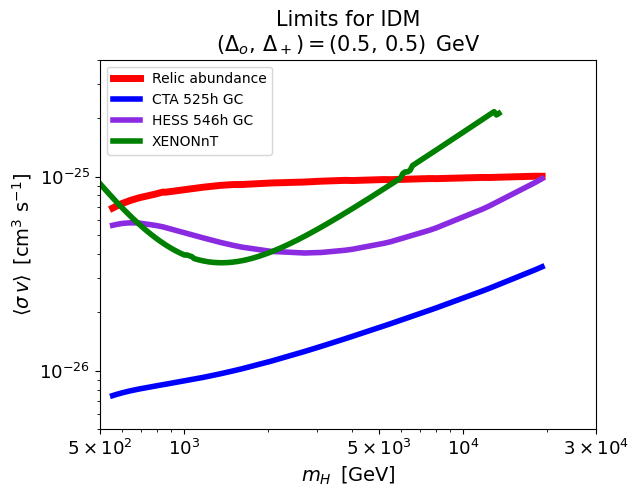

In [12]:
plt.figure(1)
plt.xscale('log')
plt.yscale('log')

plt.plot(mass_range[0],sigmav_CA[0],label='Relic abundance',color='red',linewidth=5)
plt.plot(mass_range[0],sigmav_ID[0],label='CTA 525h GC',color='blue',linestyle='solid',linewidth=4)
#axs[0,0].plot(mass_range[0],sigmav_HESS[0],label='HESS 254 h GC',color='blue',linestyle='solid',linewidth=4)
plt.plot(mass_range[0],sigmav_HESS546[0],label='HESS 546h GC',color='blueviolet',linestyle='solid',linewidth=4)
plt.plot(mass_range_DD[0],sigmav_CD[0],label='XENONnT',color='green',linewidth=4)

plt.xlim(Mi,Mf)
plt.ylim(svi,svf)
#plt.plot(np.log10(CA11['MDM']),np.log10(CA11['Lambda345']),color='black',linewidth=2.7)
plt.xticks([5e2,1e3,5e3,1e4,3e4],[r'$5 \times 10^2$',r'$10^3$',r'$5 \times 10^3$',r'$10^4$',r'$3 \times 10^4$'],fontsize=13)
plt.yticks(ticks=sv_values, labels=sv_names,fontsize=13)
#plt.yticks([1e-2,1e-1,1e0,6],[r'$10^{-2}$',r'$10^{-1}$',r'$ 1 $',r'$6$'],fontsize=12)
plt.ylabel(r"$\left< \sigma \, v \right> \,$ [cm$^3$ s$^{-1}$]",fontsize=14)
plt.legend()

plt.title(r"Limits for IDM"+"\n"+r"$(\Delta_o, \, \Delta_+) = (0.5, \, 0.5) \, $ GeV",fontsize=15)
plt.xlabel(r"$m_H\, $ [GeV]",fontsize=14)
plt.savefig("IDM_limits_b1.pdf",bbox_inches='tight')

In [49]:
for i in range(15):
    print(np.max(sigmav_CD[i]))

2.2583e-25
2.2753e-25
2.9866e-25
4.1646e-25
2.2669e-25
2.2839e-25
3.0235e-25
4.2015e-25
2.5383e-25
2.6191e-25
3.3641e-25
4.5421e-25
3.0768e-25
3.1576e-25
3.9027e-25


In [48]:
sigmav_CD[0]

array([2.2583e-25, 2.1786e-25, 2.0968e-25, 2.0229e-25, 1.9515e-25,
       1.8853e-25, 1.8191e-25, 1.7528e-25, 1.6915e-25, 1.6324e-25,
       1.5755e-25, 1.5208e-25, 1.4681e-25, 1.4174e-25, 1.3687e-25,
       1.3218e-25, 1.2766e-25, 1.2333e-25, 1.1916e-25, 1.1516e-25,
       1.1131e-25, 1.0760e-25, 1.0405e-25, 1.0064e-25, 9.7360e-26,
       9.4214e-26, 9.1192e-26, 8.8295e-26, 8.5515e-26, 8.2852e-26,
       8.0294e-26, 7.7845e-26, 7.5499e-26, 7.3250e-26, 7.1098e-26,
       6.9036e-26, 6.7065e-26, 6.5179e-26, 6.3378e-26, 6.1656e-26,
       6.0011e-26, 5.8440e-26, 5.6943e-26, 5.5514e-26, 5.4153e-26,
       5.2857e-26, 5.1626e-26, 5.0454e-26, 4.9342e-26, 4.8286e-26,
       4.7285e-26, 4.6338e-26, 4.5443e-26, 4.4597e-26, 4.3800e-26,
       4.3050e-26, 4.2345e-26, 4.1684e-26, 4.1067e-26, 4.0488e-26,
       3.9954e-26, 3.9456e-26, 3.9525e-26, 3.9110e-26, 3.8738e-26,
       3.7846e-26, 3.7529e-26, 3.7243e-26, 3.6990e-26, 3.6773e-26,
       3.6577e-26, 3.6415e-26, 3.6287e-26, 3.6181e-26, 3.6101e

<Figure size 640x480 with 0 Axes>

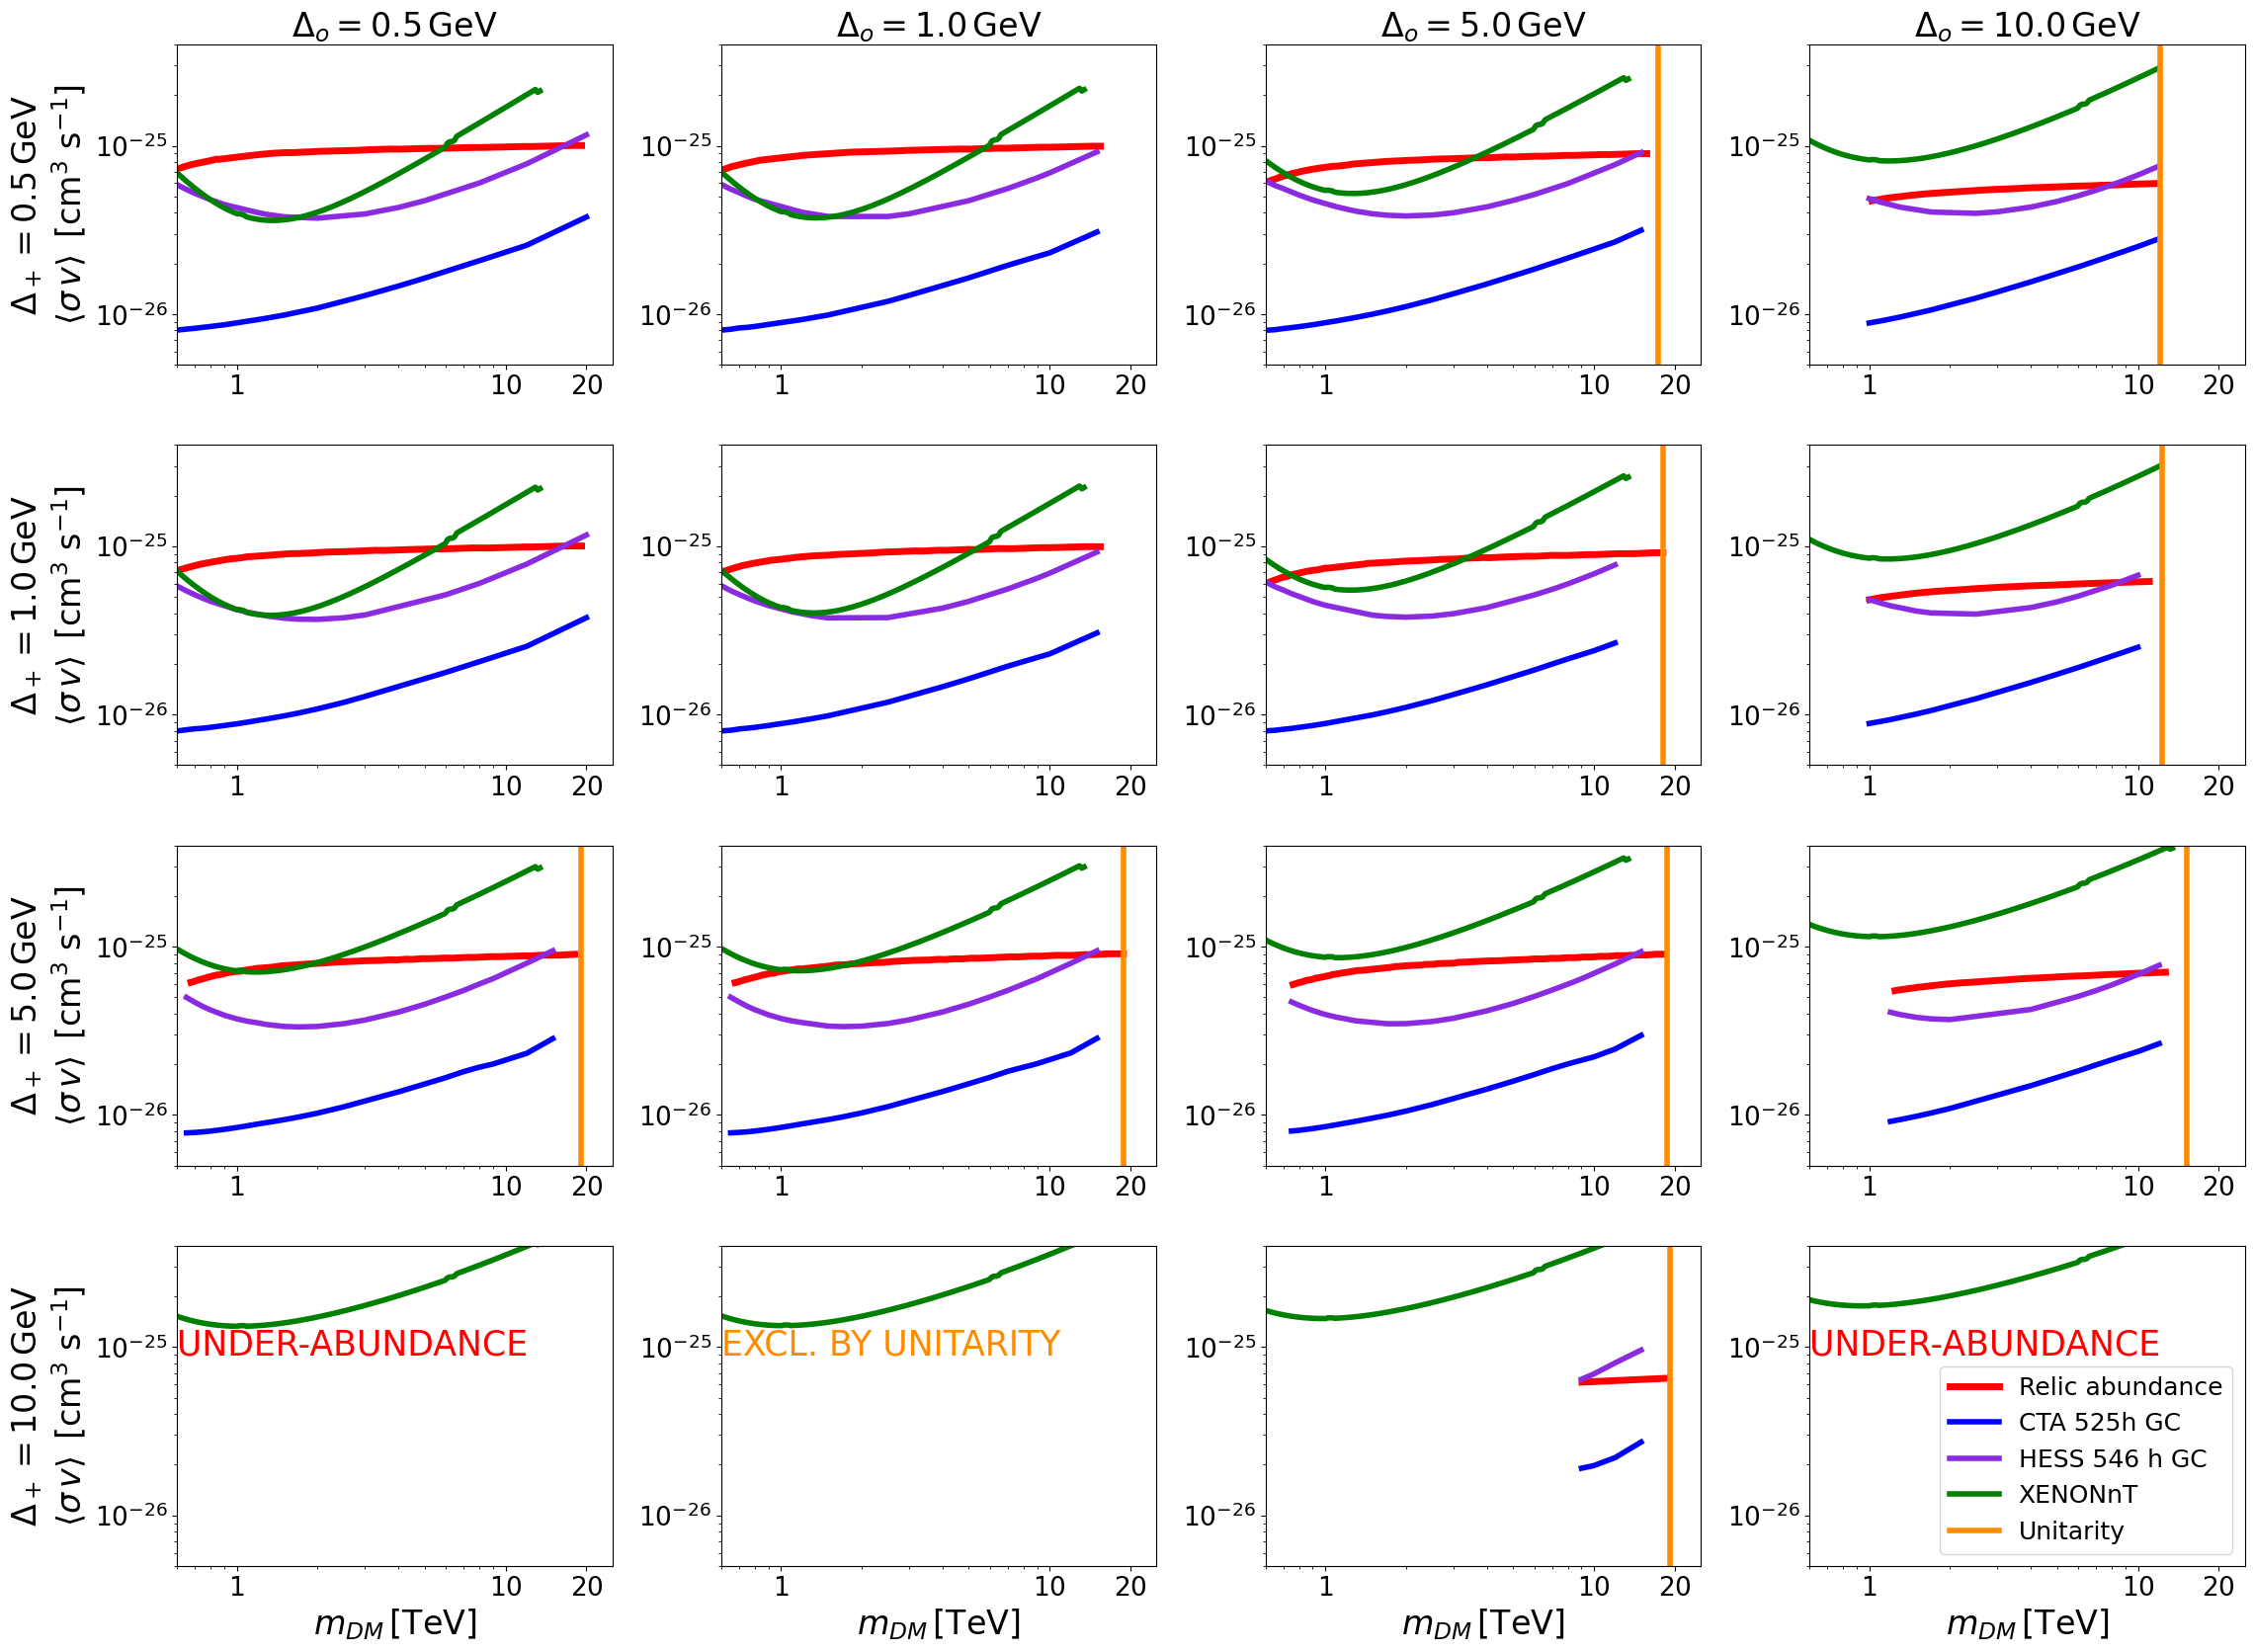

In [37]:
plt.figure(5)
fig, axs = plt.subplots(4, 4,figsize=(27,20), sharey=False)
fig.subplots_adjust(hspace=0.25,wspace=0.25)# 0.023 0.05

M_b = np.geomspace(500,30000,100)


axs[0,0].plot(mass_range[0],sigmav_CA[0],label='Relic abundance for IDM',color='red',linewidth=5)
axs[0,0].plot(mass_rangeHESS[0],sigmav_IDv2[0],label='CTA 500 h GC',color='blue',linestyle='solid',linewidth=4)
#axs[0,0].plot(mass_range[0],sigmav_HESS[0],label='HESS 254 h GC',color='blue',linestyle='solid',linewidth=4)
axs[0,0].plot(mass_rangeHESS[0],sigmav_HESS546v2[0],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[0,0].plot(mass_range_DD[0],sigmav_CD[0],label='XENONnT',color='green',linewidth=4)
#axs[0,0].plot(mass_range[0],values_ID[0]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,0].axhline(y=3e-26,color='red')
#axs[0,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[0,1].plot(mass_range[4],sigmav_CA[4],label='Relic abundance for IDM',color='red',linewidth=5)
axs[0,1].plot(mass_rangeHESS[4],sigmav_IDv2[4],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[0,1].plot(mass_range[4],sigmav_HESS[4],label='HESS',color='blue',linestyle='solid',linewidth=4)
axs[0,1].plot(mass_rangeHESS[4],sigmav_HESS546v2[4],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[0,1].plot(mass_range_DD[4],sigmav_CD[4],label='DD exclusion',color='green',linewidth=4)
#axs[0,1].plot(mass_range[3],values_ID[3]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,1].axhline(y=3e-26,color='red')
#axs[0,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[0,2].plot(mass_range[8][(mass_range[8] < mass_uni[2])],sigmav_CA[8][(mass_range[8] < mass_uni[2])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[0,2].plot(mass_rangeHESS[8][(mass_rangeHESS[8] < mass_uni[2])],sigmav_IDv2[8][(mass_rangeHESS[8] < mass_uni[2])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[0,2].plot(mass_range[8],sigmav_HESS[8],label='HESS',color='blue',linestyle='solid',linewidth=4)
axs[0,2].plot(mass_rangeHESS[8][(mass_rangeHESS[8] < mass_uni[2])],sigmav_HESS546v2[8][(mass_rangeHESS[8] < mass_uni[2])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[0,2].plot(mass_range_DD[8][(mass_range_DD[8] < mass_uni[2])],sigmav_CD[8][(mass_range_DD[8] < mass_uni[2])],label='DD exclusion',color='green',linewidth=4)
#axs[0,2].plot(mass_range[6],values_ID[6]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,2].axhline(y=3e-26,color='red')
#axs[0,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[0,3].plot(mass_range[12][(mass_range[12] < mass_uni[6])],sigmav_CA[12][(mass_range[12] < mass_uni[6])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[0,3].plot(mass_rangeHESS[12][(mass_rangeHESS[12] < mass_uni[6])],sigmav_IDv2[12][(mass_rangeHESS[12] < mass_uni[6])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[0,3].plot(mass_range[12],sigmav_HESS[12],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[0,3].plot(mass_rangeHESS[12][(mass_rangeHESS[12] < mass_uni[6])],sigmav_HESS546v2[12][(mass_rangeHESS[12] < mass_uni[6])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[0,3].plot(mass_range_DD[12][(mass_range_DD[12] < mass_uni[6])],sigmav_CD[12][(mass_range_DD[12] < mass_uni[6])],label='DD exclusion',color='green',linewidth=4)
#axs[0,3].plot(mass_range[9],values_ID[9]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[0,3].axhline(y=3e-26,color='red')
#axs[0,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[1,0].plot(mass_range[1],sigmav_CA[1],label='Relic abundance for IDM',color='red',linewidth=5)
axs[1,0].plot(mass_rangeHESS[1],sigmav_IDv2[1],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[1,0].plot(mass_range[1],sigmav_HESS[1],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[1,0].plot(mass_rangeHESS[1],sigmav_HESS546v2[1],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[1,0].plot(mass_range_DD[1],sigmav_CD[1],label='DD exclusion',color='green',linewidth=4)
#axs[1,0].plot(mass_range[1],values_ID[1]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,0].axhline(y=3e-26,color='red')
#axs[1,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[1,1].plot(mass_range[5],sigmav_CA[5],label='Relic abundance for IDM',color='red',linewidth=5)
axs[1,1].plot(mass_rangeHESS[5],sigmav_IDv2[5],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[1,1].plot(mass_range[5],sigmav_HESS[5],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[1,1].plot(mass_rangeHESS[5],sigmav_HESS546v2[5],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[1,1].plot(mass_range_DD[5],sigmav_CD[5],label='DD exclusion',color='green',linewidth=4)
#axs[1,1].plot(mass_range[4],values_ID[4]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,1].axhline(y=3e-26,color='red')
#axs[1,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[1,2].plot(mass_range[9][(mass_range[9] < mass_uni[3])],sigmav_CA[9][(mass_range[9] < mass_uni[3])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[1,2].plot(mass_rangeHESS[9][(mass_rangeHESS[9] < mass_uni[3])],sigmav_IDv2[9][(mass_rangeHESS[9] < mass_uni[3])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[1,2].plot(mass_range[9],sigmav_HESS[9],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[1,2].plot(mass_rangeHESS[9][(mass_rangeHESS[9] < mass_uni[3])],sigmav_HESS546v2[9][(mass_rangeHESS[9] < mass_uni[3])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[1,2].plot(mass_range_DD[9][(mass_range_DD[9] < mass_uni[3])],sigmav_CD[9][(mass_range_DD[9] < mass_uni[3])],label='DD exclusion',color='green',linewidth=4)
#axs[1,2].plot(mass_range[7],values_ID[7]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,2].axhline(y=3e-26,color='red')
#axs[1,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[1,3].plot(mass_range[13][(mass_range[13] < mass_uni[7])],sigmav_CA[13][(mass_range[13] < mass_uni[7])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[1,3].plot(mass_rangeHESS[13][(mass_rangeHESS[13] < mass_uni[7])],sigmav_IDv2[13][(mass_rangeHESS[13] < mass_uni[7])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[1,3].plot(mass_range[13],sigmav_HESS[13],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[1,3].plot(mass_rangeHESS[13][(mass_rangeHESS[13] < mass_uni[7])],sigmav_HESS546v2[13][(mass_rangeHESS[13] < mass_uni[7])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[1,3].plot(mass_range_DD[13][(mass_range_DD[13] < mass_uni[7])],sigmav_CD[13][(mass_range_DD[13] < mass_uni[7])],label='DD exclusion',color='green',linewidth=4)
#axs[1,3].plot(mass_range[10],values_ID[10]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[1,3].axhline(y=3e-26,color='red')
#axs[1,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[2,0].plot(mass_range[2][(mass_range[2] < mass_uni[0])],sigmav_CA[2][(mass_range[2] < mass_uni[0])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[2,0].plot(mass_rangeHESS[2][(mass_rangeHESS[2] < mass_uni[0])],sigmav_IDv2[2][(mass_rangeHESS[2] < mass_uni[0])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[2,0].plot(mass_range[2],sigmav_HESS[2],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[2,0].plot(mass_rangeHESS[2][(mass_rangeHESS[2] < mass_uni[0])],sigmav_HESS546v2[2][(mass_rangeHESS[2] < mass_uni[0])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[2,0].plot(mass_range_DD[2][(mass_range_DD[2] < mass_uni[0])],sigmav_CD[2][(mass_range_DD[2] < mass_uni[0])],label='DD exclusion',color='green',linewidth=4)
#axs[2,0].plot(mass_range[2],values_ID[2]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,0].axhline(y=3e-26,color='red')
#axs[2,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[2,1].plot(mass_range[6][(mass_range[6] < mass_uni[1])],sigmav_CA[6][(mass_range[6] < mass_uni[1])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[2,1].plot(mass_rangeHESS[6][(mass_rangeHESS[6] < mass_uni[1])],sigmav_IDv2[6][(mass_rangeHESS[6] < mass_uni[1])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[2,1].plot(mass_range[6],sigmav_HESS[6],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[2,1].plot(mass_rangeHESS[6][(mass_rangeHESS[6] < mass_uni[1])],sigmav_HESS546v2[6][(mass_rangeHESS[6] < mass_uni[1])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[2,1].plot(mass_range_DD[6][(mass_range_DD[6] < mass_uni[1])],sigmav_CD[6][(mass_range_DD[6] < mass_uni[1])],label='DD exclusion',color='green',linewidth=4)
#axs[2,1].plot(mass_range[5],values_ID[5]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,1].axhline(y=3e-26,color='red')
#axs[2,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[2,2].plot(mass_range[10][(mass_range[10] < mass_uni[4])],sigmav_CA[10][(mass_range[10] < mass_uni[4])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[2,2].plot(mass_rangeHESS[10][(mass_rangeHESS[10] < mass_uni[4])],sigmav_IDv2[10][(mass_rangeHESS[10] < mass_uni[4])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[2,2].plot(mass_range[10],sigmav_HESS[10],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[2,2].plot(mass_rangeHESS[10][(mass_rangeHESS[10] < mass_uni[4])],sigmav_HESS546v2[10][(mass_rangeHESS[10] < mass_uni[4])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[2,2].plot(mass_range_DD[10][(mass_range_DD[10] < mass_uni[4])],sigmav_CD[10][(mass_range_DD[10] < mass_uni[4])],label='DD exclusion',color='green',linewidth=4)
#axs[2,2].plot(mass_range[8],values_ID[8]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,2].axhline(y=3e-26,color='red')
#axs[2,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[2,3].plot(mass_range[14][(mass_range[14] < mass_uni[8])],sigmav_CA[14][(mass_range[14] < mass_uni[8])],label='Relic abundance constraint',color='red',linewidth=5)
axs[2,3].plot(mass_rangeHESS[14][(mass_rangeHESS[14] < mass_uni[8])],sigmav_IDv2[14][(mass_rangeHESS[14] < mass_uni[8])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[2,3].plot(mass_range[14],sigmav_HESS[14],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[2,3].plot(mass_rangeHESS[14][(mass_rangeHESS[14] < mass_uni[8])],sigmav_HESS546v2[14][(mass_rangeHESS[14] < mass_uni[8])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[2,3].plot(mass_range_DD[14][(mass_range_DD[14] < mass_uni[8])],sigmav_CD[14][(mass_range_DD[14] < mass_uni[8])],label='DD exclusion',color='green',linewidth=4)
#axs[2,3].plot(mass_range[11],values_ID[11]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,3].axhline(y=3e-26,color='red')
#axs[2,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

####################################################################################################

axs[3,0].plot(mass_range[3],sigmav_CA[3],label='IDM relic abundance',color='red',linewidth=5)
axs[3,0].plot(mass_rangeHESS[3],sigmav_IDv2[3],label='CTA 525h GC',color='blue',linestyle='solid',linewidth=4)
#axs[3,0].plot(mass_range[3],sigmav_HESS[3],label='HESS 254h GC',color='blue',linestyle='solid',linewidth=4)
axs[3,0].plot(mass_rangeHESS[3],sigmav_HESS546v2[3],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[3,0].plot(mass_range_DD[3],sigmav_CD[3],label='XENONnT',color='green',linewidth=4)
#axs[2,0].plot(mass_range[2],values_ID[2]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,0].axhline(y=3e-26,color='red')
#axs[2,0].text(6e2,3.5e-26,'WIMP thermal cross-section',color='red')

#axs[3,1].plot(mass_range[7],sigmav_CA[7],label='Relic abundance for IDM',color='red',linewidth=5)
#axs[3,1].plot(mass_range[7],sigmav_ID[7],label='CTA',color='blue',linestyle='dotted',linewidth=4)
#axs[3,1].plot(mass_range[7],sigmav_HESS[7],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[3,1].plot(mass_range[7],sigmav_HESS546[7],label='HESS 546 h GC',color='blue',linestyle='dashed',linewidth=4)
axs[3,1].plot(mass_range_DD[7],sigmav_CD[7],label='DD exclusion',color='green',linewidth=4)
#axs[2,1].plot(mass_range[5],values_ID[5]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,1].axhline(y=3e-26,color='red')
#axs[2,1].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[3,2].plot(mass_range[11][(mass_range[11] < mass_uni[5])],sigmav_CA[11][(mass_range[11] < mass_uni[5])],label='Relic abundance for IDM',color='red',linewidth=5)
axs[3,2].plot(mass_rangeHESS[11][(mass_rangeHESS[11] < mass_uni[5])],sigmav_IDv2[11][(mass_rangeHESS[11] < mass_uni[5])],label='CTA',color='blue',linestyle='solid',linewidth=4)
#axs[3,2].plot(mass_range[11],sigmav_HESS[11],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[3,2].plot(mass_rangeHESS[11][(mass_rangeHESS[11] < mass_uni[5])],sigmav_HESS546v2[11][(mass_rangeHESS[11] < mass_uni[5])],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[3,2].plot(mass_range_DD[11][(mass_range_DD[11] < mass_uni[5])],sigmav_CD[11][(mass_range_DD[11] < mass_uni[5])],label='DD exclusion',color='green',linewidth=4)
#axs[2,2].plot(mass_range[8],values_ID[8]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,2].axhline(y=3e-26,color='red')
#axs[2,2].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

axs[3,3].plot(mass_range[15],sigmav_CA[15],label='Relic abundance',color='red',linewidth=5)
axs[3,3].plot(mass_rangeHESS[15],sigmav_IDv2[15],label='CTA 525h GC',color='blue',linestyle='solid',linewidth=4)
#axs[3,3].plot(mass_range[15],sigmav_HESS[15],label='CTA',color='blue',linestyle='solid',linewidth=4)
axs[3,3].plot(mass_rangeHESS[15],sigmav_HESS546v2[15],label='HESS 546 h GC',color='blueviolet',linestyle='solid',linewidth=4)
axs[3,3].plot(mass_range_DD[15],sigmav_CD[15],label='XENONnT',color='green',linewidth=4)
axs[3,3].plot([],[],label='Unitarity',color='darkorange',linewidth=4)
#axs[2,3].plot(mass_range[11],values_ID[11]['SigmaV'],label='CTA upper limits (95% C.L.)',color='blue')
#axs[2,3].axhline(y=3e-26,color='red')
#axs[2,3].text(5e2,3.5e-26,'WIMP thermal cross-section',color='red')

#axs[0,0].vlines(mass_uni[0],1e-27,1e-24,color='darkorange',linewidth=5)
#axs[1,0].vlines(mass_uni[1],1e-27,1e-24,color='darkorange',linewidth=5)
axs[2,0].vlines(mass_uni[0],1e-27,1e-24,color='darkorange',linewidth=4)

axs[2,1].vlines(mass_uni[1],1e-27,1e-24,color='darkorange',linewidth=4)
#axs[1,1].vlines(mass_uni[4],1e-27,1e-24,color='darkorange',linewidth=5)
#axs[2,1].vlines(mass_uni[5],1e-27,1e-24,color='darkorange',linewidth=5)

axs[0,2].vlines(mass_uni[2],1e-27,1e-24,color='darkorange',linewidth=4)
axs[1,2].vlines(mass_uni[3],1e-27,1e-24,color='darkorange',linewidth=4)
axs[2,2].vlines(mass_uni[4],1e-27,1e-24,color='darkorange',linewidth=4)
axs[3,2].vlines(mass_uni[5],1e-27,1e-24,color='darkorange',linewidth=4)

axs[0,3].vlines(mass_uni[6],1e-27,1e-24,color='darkorange',linewidth=4)
axs[1,3].vlines(mass_uni[7],1e-27,1e-24,color='darkorange',linewidth=4)
axs[2,3].vlines(mass_uni[8],1e-27,1e-24,color='darkorange',linewidth=4)


#axs[0,0].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[0]),color='darkorange')
#axs[1,0].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[1]),color='darkorange')
#axs[2,0].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[2]),color='darkorange')

#axs[0,1].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[3]),color='darkorange')
#axs[1,1].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[4]),color='darkorange')
#axs[2,1].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[5]),color='darkorange')

#axs[0,2].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[6]),color='darkorange')
#axs[1,2].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[7]),color='darkorange')
#axs[2,2].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[8]),color='darkorange')
#axs[3,2].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[9]),color='darkorange')

#axs[0,3].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[10]),color='darkorange')
#axs[1,3].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[11]),color='darkorange')
#axs[2,3].fill_between(M_b,1e-27,1e-24,where=(M_b>mass_uni[12]),color='darkorange')

####################################################################################################

axs[3,3].legend(fontsize=18,bbox_to_anchor = [1,0],loc='lower right')

axs[0,0].set_title(r"$\Delta_o = 0.5 \, $GeV",fontsize=24)
axs[0,1].set_title(r"$\Delta_o = 1.0 \, $GeV",fontsize=24)
axs[0,2].set_title(r"$\Delta_o = 5.0 \, $GeV",fontsize=24)
axs[0,3].set_title(r"$\Delta_o = 10.0 \, $GeV",fontsize=24)

axs[0,0].set_ylabel(r"$\Delta_+ = 0.5 \, $GeV"+"\n"+r"$\left< \sigma \, v \right> \,$ [cm$^3$ s$^{-1}$]",fontsize=24)
axs[1,0].set_ylabel(r"$\Delta_+ = 1.0 \, $GeV"+"\n"+r"$\left< \sigma \, v \right> \,$ [cm$^3$ s$^{-1}$]",fontsize=24)
axs[2,0].set_ylabel(r"$\Delta_+ = 5.0 \, $GeV"+"\n"+r"$\left< \sigma \, v \right> \,$ [cm$^3$ s$^{-1}$]",fontsize=24)
axs[3,0].set_ylabel(r"$\Delta_+ = 10.0 \, $GeV"+"\n"+r"$\left< \sigma \, v \right> \,$ [cm$^3$ s$^{-1}$]",fontsize=24)

axs[3,0].set_xlabel(r"$m_{DM} \, $[TeV]",fontsize=24)
axs[3,1].set_xlabel(r"$m_{DM} \, $[TeV]",fontsize=24)
axs[3,2].set_xlabel(r"$m_{DM} \, $[TeV]",fontsize=24)
axs[3,3].set_xlabel(r"$m_{DM} \, $[TeV]",fontsize=24)

axs[0,0].set_yscale('log')
axs[0,1].set_yscale('log')
axs[0,2].set_yscale('log')
axs[0,3].set_yscale('log')

axs[1,0].set_yscale('log')
axs[1,1].set_yscale('log')
axs[1,2].set_yscale('log')
axs[1,3].set_yscale('log')

axs[2,0].set_yscale('log')
axs[2,1].set_yscale('log')
axs[2,2].set_yscale('log')
axs[2,3].set_yscale('log')

axs[3,0].set_yscale('log')
axs[3,1].set_yscale('log')
axs[3,2].set_yscale('log')
axs[3,3].set_yscale('log')

axs[0,0].set_xscale('log')
axs[0,1].set_xscale('log')
axs[0,2].set_xscale('log')
axs[0,3].set_xscale('log')

axs[1,0].set_xscale('log')
axs[1,1].set_xscale('log')
axs[1,2].set_xscale('log')
axs[1,3].set_xscale('log')

axs[2,0].set_xscale('log')
axs[2,1].set_xscale('log')
axs[2,2].set_xscale('log')
axs[2,3].set_xscale('log')

axs[3,0].set_xscale('log')
axs[3,1].set_xscale('log')
axs[3,2].set_xscale('log')
axs[3,3].set_xscale('log')

####################################################################################################

#axs[3,0].grid()

[svi,svf] = [5e-27,4e-25]

axs[0,0].set_ylim(svi,svf)
axs[0,1].set_ylim(svi,svf)
axs[0,2].set_ylim(svi,svf)
axs[0,3].set_ylim(svi,svf)

axs[1,0].set_ylim(svi,svf)
axs[1,1].set_ylim(svi,svf)
axs[1,2].set_ylim(svi,svf)
axs[1,3].set_ylim(svi,svf)

axs[2,0].set_ylim(svi,svf)
axs[2,1].set_ylim(svi,svf)
axs[2,2].set_ylim(svi,svf)
axs[2,3].set_ylim(svi,svf)

axs[3,0].set_ylim(svi,svf)
axs[3,1].set_ylim(svi,svf)
axs[3,2].set_ylim(svi,svf)
axs[3,3].set_ylim(svi,svf)

[Mi,Mf] = [6e2,2.5e4]

axs[0,0].set_xlim(Mi,Mf)
axs[0,1].set_xlim(Mi,Mf)
axs[0,2].set_xlim(Mi,Mf)
axs[0,3].set_xlim(Mi,Mf)

axs[1,0].set_xlim(Mi,Mf)
axs[1,1].set_xlim(Mi,Mf)
axs[1,2].set_xlim(Mi,Mf)
axs[1,3].set_xlim(Mi,Mf)

axs[2,0].set_xlim(Mi,Mf)
axs[2,1].set_xlim(Mi,Mf)
axs[2,2].set_xlim(Mi,Mf)
axs[2,3].set_xlim(Mi,Mf)

axs[3,0].set_xlim(Mi,Mf)
axs[3,1].set_xlim(Mi,Mf)
axs[3,2].set_xlim(Mi,Mf)
axs[3,3].set_xlim(Mi,Mf)

mass_values = [1e3,1e4,2e4]
mass_names = [r'$1$',r'$10$',r'$ 20 $']

axs[0,0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[0,1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[0,2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[0,3].set_xticks(ticks=np.array([1e3,1e4,2e4]), labels=mass_names,fontsize=19)

axs[1,0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[1,1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[1,2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[1,3].set_xticks(ticks=np.array([1e3,1e4,2e4]), labels=mass_names,fontsize=19)

axs[2,0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[2,1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[2,2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[2,3].set_xticks(ticks=np.array([1e3,1e4,2e4]), labels=mass_names,fontsize=19)

axs[3,0].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[3,1].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[3,2].set_xticks(ticks=mass_values, labels=mass_names,fontsize=19)
axs[3,3].set_xticks(ticks=np.array([1e3,1e4,2e4]), labels=mass_names,fontsize=19)

axs[3,0].text(6e2,9e-26,'UNDER-ABUNDANCE',color='red',fontsize=25)
axs[3,1].text(6e2,9e-26,'EXCL. BY UNITARITY',color='darkorange',fontsize=25)
axs[3,3].text(6e2,9e-26,'UNDER-ABUNDANCE',color='red',fontsize=25)


sv_values = [1e-26,1e-25]
sv_names = [r'$10^{-26}$',r'$10^{-25}$']

axs[0,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[1,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[2,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[3,0].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)

axs[0,1].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[1,1].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[2,1].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[3,1].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)

axs[0,2].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[1,2].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[2,2].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[3,2].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)

axs[0,3].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[1,3].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[2,3].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)
axs[3,3].set_yticks(ticks=sv_values, labels=sv_names,fontsize=19)

#fig.suptitle("Limits to IDM",fontsize= 25)
plt.savefig("IDM_limits_v2_final.pdf")

In [16]:
sigmav_HESS546v2[4]

array([5.91031852e-26, 5.66723239e-26, 5.60775258e-26, 5.54981431e-26,
       5.49332790e-26, 5.29915600e-26, 4.94729764e-26, 4.81557392e-26,
       4.77560647e-26, 4.58691351e-26, 4.51364984e-26, 4.30791542e-26,
       4.09006465e-26, 4.06416409e-26, 3.80988131e-26, 3.79399721e-26,
       3.56398459e-26, 3.53996826e-26, 3.48545378e-26, 3.47722140e-26,
       3.52406652e-26, 3.60833228e-26, 3.73393904e-26, 3.80385377e-26,
       3.99508979e-26, 4.08751309e-26, 4.45181845e-26, 4.59125398e-26,
       5.09415963e-26, 5.27262970e-26, 5.47006740e-26, 6.40449465e-26,
       6.66079731e-26, 8.47950938e-26, 8.84788231e-26, 9.24156232e-26])

In [17]:
sigmav_HESS546[4]

array([5.59089143e-26, 5.62956571e-26, 5.66479361e-26, 5.69595534e-26,
       5.71523243e-26, 5.75906038e-26, 5.76748080e-26, 5.78391650e-26,
       5.72014115e-26, 5.61781408e-26, 5.52384585e-26, 4.76681177e-26,
       4.56096268e-26, 4.41671884e-26, 4.21959836e-26, 4.08147570e-26,
       4.04917283e-26, 4.06271085e-26, 4.15310133e-26, 4.40065014e-26,
       4.48011976e-26, 4.92989278e-26, 5.05610571e-26, 5.94431683e-26,
       6.15252510e-26, 7.88952695e-26, 8.24088707e-26])

IndexError: string index out of range